# Method B — Dynamic Meta-path Search 실험

> **목적**: 05 EDA가 정한 설계 prior(L=2, per-edge depth, 키워드 IDF 가중)를
> 실제 학습으로 검증·확정한다. baseline(methodA_relation_gating.ipynb, static relation-gating)과 분리.
>
> **근거 문서**: `docs/methodology_metapath_search.md` / EDA: `eda/notebooks/05_metapath_topology_eda.ipynb`
>
> | 실험 | IDF | L | 역할 |
> |---|---|---|---|
> | exp07 | off | 2 | baseline (현재 그래프, test-eval 버그 수정 후 재실행) |
> | exp08 | **on** | 2 | IDF 효과 (O2) |
> | exp09 | on | **3** | L-sweep (parsimony 규칙) |
> | exp10 | off | 2 | learned 1/2-hop readout: `H¹,H²` 가중합 성능 검증 |
> | exp11 | off | 1 | no-basket, learned_hop_sum L=1 |
> | exp12 | off | 2 | no-basket, learned_hop_sum L=2 |
> | exp13 | off | 3 | no-basket, learned_hop_sum L=3 |
>
> **parsimony 결정규칙**: L=3(exp09)이 L=2(exp08)를 시드별 noise(std) 넘는 마진으로
> 이겨야만 L=3 채택, 아니면 L=2. (L=3은 파라미터↑ 과적합 위험 + nnz 2.4배)

## 0. 환경 설정 (공통)

In [1]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

_nb_file = globals().get('__vsc_ipynb_file__', None)
_anchor  = Path(_nb_file).resolve().parent if _nb_file else Path.cwd()
ROOT = None
for _p in [_anchor] + list(_anchor.parents):
    if (_p / "CLAUDE.md").exists():
        ROOT = str(_p); break
if ROOT is None:
    ROOT = str(_anchor)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

from experiments.exp_utils import (
    run_experiment, load_experiment, compare_experiments,
    plot_alpha_heatmap, plot_training_curve, print_metrics_table, print_recommendations
)

# Method B 실험 config (methodA_relation_gating.ipynb와 동일 헬퍼 재사용)
CFG = {
    'exp07': 'experiments/configs/exp07_copurchase_binary.yaml',   # baseline (IDF off, L=2)
    'exp08': 'experiments/configs/exp08_idf_keyword.yaml',         # IDF on, L=2
    'exp09': 'experiments/configs/exp09_idf_L3.yaml',              # IDF on, L=3
    'exp10': 'experiments/configs/exp10_learned_hop_readout.yaml', # H¹/H² learned readout
    'exp11': 'experiments/configs/exp11_no_basket_L1_hop_readout.yaml',
    'exp12': 'experiments/configs/exp12_no_basket_L2_hop_readout.yaml',
    'exp13': 'experiments/configs/exp13_no_basket_L3_hop_readout.yaml',
    'exp14': 'experiments/configs/exp14_regularized.yaml',        # exp10+정규화
    'exp15': 'experiments/configs/exp15_pos_weight.yaml',         # exp10+pos_weight4.5
    'exp16': 'experiments/configs/exp16_hidden64.yaml',           # exp10+hidden64
    'exp18': 'experiments/configs/exp18_multihop_1attn.yaml',     # 멀티홉 1-어텐션 (제품공간 sim, 2홉 후보 최고)
    # --- exp18 기반 튜닝 + 2홉 임계 스윕 + 애블레이션 ---
    'exp19': 'experiments/configs/exp19_reg_on18.yaml',           # exp18+정규화
    'exp20': 'experiments/configs/exp20_posw_on18.yaml',          # exp18+pos_weight
    'exp21': 'experiments/configs/exp21_h64_on18.yaml',           # exp18+hidden64
    'exp22': 'experiments/configs/exp22_2hop_kw3.yaml',           # sim 임계 kw≥3 (조밀) ★최고 0.6852
    'exp23': 'experiments/configs/exp23_2hop_kw8.yaml',           # sim 임계 kw≥8 (희소)
    'exp24': 'experiments/configs/exp24_2hop_kw2.yaml',           # sim 임계 kw≥2 (⚠ OOM 위험)
    'exp25': 'experiments/configs/exp25_multihop_2layer.yaml',    # exp18 2층 스택 (깊이 검증)
    'exp27': 'experiments/configs/exp27_no_sim_1layer.yaml',      # sim 제거 1홉 (애블레이션, 퇴화 기준)
    'exp31': 'experiments/configs/exp31_2hop_kw3_ip1.yaml',       # exp22(kw≥3) + IP 임계 2→1 (커버리지↑)
}
print('ROOT:', ROOT)
for _k, _p in CFG.items():
    assert os.path.exists(_p), f"{_k} config 없음: {_p}"
print(f'config {len(CFG)}종 확인 완료')

ROOT: C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework
config 20종 확인 완료


## 1. 실험 실행

각 셀은 `run_experiment` → 학습 → 평가 → 결과 저장(`experiments/results/{name}/`). GPU 권장.

In [2]:
r07 = run_experiment(CFG['exp07'], 'exp07_copurchase_binary')
print_metrics_table(r07)

c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[exp07_copurchase_binary] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0825 val_pr_auc=0.4280 val_auc=0.6858
[010] loss_w=0.9004 val_pr_auc=0.6311 val_auc=0.7899
[020] loss_w=0.7467 val_pr_auc=0.7220 val_auc=0.8405
[030] loss_w=0.5224 val_pr_auc=0.7172 val_auc=0.8513
[040] loss_w=0.4025 val_pr_auc=0.6767 val_auc=0.8452
[050] loss_w=0.3086 val_pr_auc=0.7028 val_auc=0.8437
early stop @ 54 (best pr_auc=0.7301)
TEST: {'pr_auc': 0.6354, 'auc_roc': 0.8437, 'threshold': 0.6731, 'f1': 0.6387}
[exp07_copurchase_binary] 완료 → experiments/results\exp07_copurchase_binary

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7665    0.9125    0.7306     0.4774
val        0.7301    0.8503    0.6548     0.8297
test       0.6354    0.8437    0.6387     0.6731

[random]   0.2360


In [3]:
r08 = run_experiment(CFG['exp08'], 'exp08_idf_keyword')
print_metrics_table(r08)

[exp08_idf_keyword] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0778 val_pr_auc=0.4038 val_auc=0.6565
[010] loss_w=0.8741 val_pr_auc=0.6585 val_auc=0.8039
[020] loss_w=0.6117 val_pr_auc=0.6889 val_auc=0.8389
[030] loss_w=0.4478 val_pr_auc=0.7049 val_auc=0.8444
[040] loss_w=0.3455 val_pr_auc=0.7011 val_auc=0.8439
[050] loss_w=0.2920 val_pr_auc=0.7033 val_auc=0.8426
early stop @ 54 (best pr_auc=0.7166)
TEST: {'pr_auc': 0.6557, 'auc_roc': 0.8514, 'threshold': 0.7713, 'f1': 0.6341}
[exp08_idf_keyword] 완료 → experiments/results\exp08_idf_keyword

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7957    0.9361    0.7876     0.7787
val        0.7166    0.8514    0.6686     0.8855
test       0.6557    0.8514    0.6341     0.7713

[random]   0.2360


In [4]:
r09 = run_experiment(CFG['exp09'], 'exp09_idf_L3')
print_metrics_table(r09)

[exp09_idf_L3] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0505 val_pr_auc=0.4291 val_auc=0.6464
[010] loss_w=0.9433 val_pr_auc=0.5639 val_auc=0.7542
[020] loss_w=0.7669 val_pr_auc=0.7024 val_auc=0.8334
[030] loss_w=0.4782 val_pr_auc=0.7244 val_auc=0.8496
[040] loss_w=0.4661 val_pr_auc=0.7190 val_auc=0.8457
[050] loss_w=0.2973 val_pr_auc=0.6769 val_auc=0.8418
early stop @ 56 (best pr_auc=0.7292)
TEST: {'pr_auc': 0.6487, 'auc_roc': 0.8463, 'threshold': 0.6542, 'f1': 0.6276}
[exp09_idf_L3] 완료 → experiments/results\exp09_idf_L3

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.7993    0.9321    0.7588     0.5751
val        0.7292    0.8523    0.6628     0.8224
test       0.6487    0.8463    0.6276     0.6542

[random]   0.2360


### exp10 — Learned 1/2-hop Influence Readout

exp07과 동일한 그래프/HP에서 classifier 입력만 `H²` 단독이 아니라 `softmax(β₁,β₂)·[H¹,H²]` 가중합으로 바꾼다.  
목적은 `S = λ₁·A_learned¹ + λ₂·A_learned²` 아이디어가 성공확률 예측 성능에서도 baseline을 이기는지 검증하는 것이다.

In [5]:
r10 = run_experiment(CFG['exp10'], 'exp10_learned_hop_readout')
print_metrics_table(r10)

[exp10_learned_hop_readout] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0665 val_pr_auc=0.3971 val_auc=0.6677
[010] loss_w=0.9236 val_pr_auc=0.6068 val_auc=0.7818
[020] loss_w=0.8119 val_pr_auc=0.6867 val_auc=0.8382
[030] loss_w=0.7343 val_pr_auc=0.7043 val_auc=0.8410
[040] loss_w=0.5897 val_pr_auc=0.7179 val_auc=0.8572
[050] loss_w=0.5289 val_pr_auc=0.7280 val_auc=0.8595
[060] loss_w=0.3739 val_pr_auc=0.7217 val_auc=0.8540
[070] loss_w=0.3705 val_pr_auc=0.6890 val_auc=0.8404
[080] loss_w=0.3039 val_pr_auc=0.6681 val_auc=0.8391
early stop @ 81 (best pr_auc=0.7381)
TEST: {'pr_auc': 0.6684, 'auc_roc': 0.856, 'threshold': 0.8665, 'f1': 0.6545}
[exp10_learned_hop_readout] 완료 → experiments/results\exp10_learned_hop_readout

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8064    0.9435    0.7822     0.8422
val        0.7381    0.8633    0.6720     0.8469
test       0.6684    0.8560    0.6545     0.8665

[random]   0.2360


### exp11~13 — No-basket L-sweep with Learned Hop Readout

동반구매 엣지(`co_offline`, `co_quick`)가 지배적인 shortcut인지 확인하기 위해 제거한 그래프에서 L=1/2/3을 다시 비교한다.  
단, 모든 실험은 exp10과 동일하게 `readout_hop_mode=learned_hop_sum`으로 고정해 readout 차이를 통제한다.

In [6]:
r11 = run_experiment(CFG['exp11'], 'exp11_no_basket_L1_hop_readout')
print_metrics_table(r11)

[exp11_no_basket_L1_hop_readout] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0590 val_pr_auc=0.3852 val_auc=0.6739
[010] loss_w=0.9792 val_pr_auc=0.4680 val_auc=0.7196
[020] loss_w=0.9108 val_pr_auc=0.4815 val_auc=0.7239
[030] loss_w=0.7898 val_pr_auc=0.5421 val_auc=0.7784
[040] loss_w=0.6569 val_pr_auc=0.5326 val_auc=0.7943
[050] loss_w=0.5412 val_pr_auc=0.5506 val_auc=0.7992
[060] loss_w=0.4437 val_pr_auc=0.5832 val_auc=0.8124
[070] loss_w=0.4363 val_pr_auc=0.5869 val_auc=0.8095
[080] loss_w=0.3346 val_pr_auc=0.5801 val_auc=0.8044
early stop @ 88 (best pr_auc=0.5917)
TEST: {'pr_auc': 0.5786, 'auc_roc': 0.8223, 'threshold': 0.6186, 'f1': 0.6098}
[exp11_no_basket_L1_hop_readout] 완료 → experiments/results\exp11_no_basket_L1_hop_readout

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8068    0.9452    0.7730     0.7415
val        0.5917    0.8151    0.5930     0.5378
test       0.5786    0.8223    0.6098     0.6186

[random]  

In [7]:
r12 = run_experiment(CFG['exp12'], 'exp12_no_basket_L2_hop_readout')
print_metrics_table(r12)

[exp12_no_basket_L2_hop_readout] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0609 val_pr_auc=0.3947 val_auc=0.6752
[010] loss_w=0.9538 val_pr_auc=0.4654 val_auc=0.7143
[020] loss_w=0.8913 val_pr_auc=0.5022 val_auc=0.7586
[030] loss_w=0.7247 val_pr_auc=0.5530 val_auc=0.7915
[040] loss_w=0.5879 val_pr_auc=0.5322 val_auc=0.7880
[050] loss_w=0.5174 val_pr_auc=0.5549 val_auc=0.8004
[060] loss_w=0.4828 val_pr_auc=0.5712 val_auc=0.8049
[070] loss_w=0.4667 val_pr_auc=0.5370 val_auc=0.7831
[080] loss_w=0.3940 val_pr_auc=0.5158 val_auc=0.7963
[090] loss_w=0.3768 val_pr_auc=0.4810 val_auc=0.7919
early stop @ 90 (best pr_auc=0.5712)
TEST: {'pr_auc': 0.568, 'auc_roc': 0.8237, 'threshold': 0.637, 'f1': 0.6169}
[exp12_no_basket_L2_hop_readout] 완료 → experiments/results\exp12_no_basket_L2_hop_readout

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8065    0.9389    0.7501     0.6255
val        0.5712    0.8049    0.5956     0.5646
test     

In [8]:
r13 = run_experiment(CFG['exp13'], 'exp13_no_basket_L3_hop_readout')
print_metrics_table(r13)

[exp13_no_basket_L3_hop_readout] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0744 val_pr_auc=0.3699 val_auc=0.6701
[010] loss_w=0.9564 val_pr_auc=0.4707 val_auc=0.7140
[020] loss_w=0.9146 val_pr_auc=0.4819 val_auc=0.7338
[030] loss_w=0.7796 val_pr_auc=0.5464 val_auc=0.7867
[040] loss_w=0.6363 val_pr_auc=0.5440 val_auc=0.7932
[050] loss_w=0.5189 val_pr_auc=0.5775 val_auc=0.8067
[060] loss_w=0.4379 val_pr_auc=0.5910 val_auc=0.8127
[070] loss_w=0.4650 val_pr_auc=0.5745 val_auc=0.8033
[080] loss_w=0.2810 val_pr_auc=0.5842 val_auc=0.8053
[090] loss_w=0.2618 val_pr_auc=0.5885 val_auc=0.8034
[100] loss_w=0.1852 val_pr_auc=0.5703 val_auc=0.7894
[110] loss_w=0.1580 val_pr_auc=0.5452 val_auc=0.7924
early stop @ 114 (best pr_auc=0.5994)
TEST: {'pr_auc': 0.5484, 'auc_roc': 0.8093, 'threshold': 0.7544, 'f1': 0.5856}
[exp13_no_basket_L3_hop_readout] 완료 → experiments/results\exp13_no_basket_L3_hop_readout

split      PR-AUC   AUC-ROC   F1@best  threshold
-----------------------------------------------

### exp14~16 — exp10 튜닝 (정규화·pos_weight·용량)

In [9]:
r14 = run_experiment(CFG['exp14'], 'exp14_regularized'); print_metrics_table(r14)
r15 = run_experiment(CFG['exp15'], 'exp15_pos_weight'); print_metrics_table(r15)
r16 = run_experiment(CFG['exp16'], 'exp16_hidden64'); print_metrics_table(r16)

[exp14_regularized] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0706 val_pr_auc=0.3970 val_auc=0.6710
[010] loss_w=0.9830 val_pr_auc=0.4414 val_auc=0.7005
[020] loss_w=0.9414 val_pr_auc=0.4677 val_auc=0.7185
[030] loss_w=0.8541 val_pr_auc=0.4960 val_auc=0.7533
[040] loss_w=0.7652 val_pr_auc=0.5429 val_auc=0.7844
[050] loss_w=0.7116 val_pr_auc=0.5311 val_auc=0.7848
[060] loss_w=0.6108 val_pr_auc=0.5271 val_auc=0.7829
[070] loss_w=0.8506 val_pr_auc=0.5361 val_auc=0.7855
early stop @ 70 (best pr_auc=0.5429)
TEST: {'pr_auc': 0.5586, 'auc_roc': 0.8079, 'threshold': 0.6679, 'f1': 0.5875}
[exp14_regularized] 완료 → experiments/results\exp14_regularized

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.5850    0.8429    0.6099     0.6418
val        0.5429    0.7844    0.5374     0.6681
test       0.5586    0.8079    0.5875     0.6679

[random]   0.2360
[exp15_pos_weight] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.2639 val_pr_auc=0.4220

### exp18 — 멀티홉 1-어텐션 (가중합→어텐션→스코어)

In [10]:
r18 = run_experiment(CFG['exp18'], 'exp18_multihop_1attn'); print_metrics_table(r18)

[exp18_multihop_1attn] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0776 val_pr_auc=0.3779 val_auc=0.6872
[010] loss_w=0.9348 val_pr_auc=0.5390 val_auc=0.7505
[020] loss_w=0.7827 val_pr_auc=0.7010 val_auc=0.8403
[030] loss_w=0.7027 val_pr_auc=0.7189 val_auc=0.8548
[040] loss_w=0.5811 val_pr_auc=0.7315 val_auc=0.8643
[050] loss_w=0.5971 val_pr_auc=0.7247 val_auc=0.8634
[060] loss_w=0.4046 val_pr_auc=0.7250 val_auc=0.8655
[070] loss_w=0.3527 val_pr_auc=0.6641 val_auc=0.8475
[080] loss_w=0.2831 val_pr_auc=0.6558 val_auc=0.8402
early stop @ 85 (best pr_auc=0.7378)
TEST: {'pr_auc': 0.6681, 'auc_roc': 0.8596, 'threshold': 0.8262, 'f1': 0.6421}
[exp18_multihop_1attn] 완료 → experiments/results\exp18_multihop_1attn

split      PR-AUC   AUC-ROC   F1@best  threshold
------------------------------------------------
train      0.8171    0.9476    0.7820     0.7302
val        0.7378    0.8692    0.6667     0.8153
test       0.6681    0.8596    0.6421     0.8262

[random]   0.2360


### exp19~27 — exp18 기반 튜닝·2홉 임계 스윕·깊이/애블레이션

exp18(멀티홉 1-어텐션, 제품공간 sim)을 기준으로:
- **exp19~21**: 정규화·pos_weight·hidden64 튜닝
- **exp22~24**: sim 엣지 2홉 임계 스윕 (kw≥3 조밀 / kw≥8 희소 / kw≥2 ⚠OOM 위험)
- **exp25**: 2층 스택 (깊이 더 쌓으면? → 손해 검증)
- **exp27**: sim 제거 1홉 (애블레이션 — PR-AUC 최고지만 추천 순회 불가 = **퇴화 기준점**)

> 각 실험은 try/except로 감싸 OOM·오류 시 건너뜀 (Run All 안전).

In [11]:
# exp19~31 일괄 실행 (OOM·오류 시 건너뜀)
_multihop = {
    'exp19': 'exp19_reg_on18', 'exp20': 'exp20_posw_on18', 'exp21': 'exp21_h64_on18',
    'exp22': 'exp22_2hop_kw3', 'exp23': 'exp23_2hop_kw8', 'exp24': 'exp24_2hop_kw2',
    'exp25': 'exp25_multihop_2layer', 'exp27': 'exp27_no_sim_1layer',
    'exp31': 'exp31_2hop_kw3_ip1',   # ★ exp22(kw≥3) + IP 임계 2→1 — 최종 후보 튜닝
}
_R = {}
for _key, _name in _multihop.items():
    try:
        _R[_name] = run_experiment(CFG[_key], _name)
        _m = _R[_name]['metrics']['test']
        print(f"  {_name:26s} test PR-AUC={_m['pr_auc']:.4f}  AUC={_m['auc_roc']:.4f}")
    except Exception as _e:
        print(f"  {_name:26s} → 건너뜀 ({type(_e).__name__}: {str(_e)[:60]})")
        import torch; torch.cuda.empty_cache() if torch.cuda.is_available() else None

# exp22 vs exp31 직접 대조 (sim_ip 임계 2 vs 1)
if 'exp22_2hop_kw3' in _R and 'exp31_2hop_kw3_ip1' in _R:
    _a = _R['exp22_2hop_kw3']['metrics']['test']['pr_auc']
    _b = _R['exp31_2hop_kw3_ip1']['metrics']['test']['pr_auc']
    print(f"\n  [exp22(ip≥2) vs exp31(ip≥1)] {_a:.4f} vs {_b:.4f}  Δ={_b-_a:+.4f}  → "
          + ("exp31(ip≥1) 우세" if _b-_a > 0.003 else "exp22(ip≥2) 우세" if _b-_a < -0.003 else "사실상 동률"))

[exp19_reg_on18] 네트워크 변경/지문 불일치 감지 → 자동 재학습.
[001] loss_w=1.0802 val_pr_auc=0.3663 val_auc=0.6628
[010] loss_w=0.9714 val_pr_auc=0.4174 val_auc=0.6894
[020] loss_w=0.9322 val_pr_auc=0.4735 val_auc=0.7250
[030] loss_w=0.8574 val_pr_auc=0.4897 val_auc=0.7549
[040] loss_w=0.7348 val_pr_auc=0.5297 val_auc=0.7741
[050] loss_w=0.6847 val_pr_auc=0.5340 val_auc=0.7836
[060] loss_w=0.6190 val_pr_auc=0.5387 val_auc=0.7896
[070] loss_w=0.5589 val_pr_auc=0.5455 val_auc=0.7980
[080] loss_w=0.5133 val_pr_auc=0.5590 val_auc=0.7985
[090] loss_w=0.4695 val_pr_auc=0.5566 val_auc=0.7975
[100] loss_w=0.5234 val_pr_auc=0.5620 val_auc=0.8013
[110] loss_w=0.4414 val_pr_auc=0.5465 val_auc=0.7921
[120] loss_w=0.3957 val_pr_auc=0.5194 val_auc=0.7897
[130] loss_w=0.5351 val_pr_auc=0.4942 val_auc=0.7433
[140] loss_w=0.5999 val_pr_auc=0.5264 val_auc=0.7895
[150] loss_w=0.4891 val_pr_auc=0.5385 val_auc=0.7935
[160] loss_w=0.4246 val_pr_auc=0.5375 val_auc=0.7997
early stop @ 163 (best pr_auc=0.5755)
TEST: {'pr_auc':

## 2. 결과 비교 — IDF 효과 & L-sweep

In [12]:
# 전체 실험 지표 비교 (train/val/test) — 저장된 결과 기준
_compare_names = [
    'exp07_copurchase_binary', 'exp08_idf_keyword', 'exp09_idf_L3',
    'exp10_learned_hop_readout',
    'exp11_no_basket_L1_hop_readout', 'exp12_no_basket_L2_hop_readout', 'exp13_no_basket_L3_hop_readout',
    'exp14_regularized', 'exp15_pos_weight', 'exp16_hidden64',
    'exp18_multihop_1attn',
    'exp19_reg_on18', 'exp20_posw_on18', 'exp21_h64_on18',
    'exp22_2hop_kw3', 'exp23_2hop_kw8', 'exp24_2hop_kw2',
    'exp25_multihop_2layer', 'exp27_no_sim_1layer', 'exp31_2hop_kw3_ip1',
]
# 결과 폴더가 있는 것만 비교 (건너뛴 실험 제외)
_avail = [n for n in _compare_names if os.path.exists(f'experiments/results/{n}')]
df = compare_experiments(_avail).sort_values('test_pr_auc', ascending=False)
try:
    from IPython.display import display; display(df)
except Exception:
    print(df.to_string())

,exp,train_pr_auc,train_auc_roc,train_f1,val_pr_auc,val_auc_roc,val_f1,test_pr_auc,test_auc_roc,test_f1,note
13,exp21_h64_on18,0.7801,0.9309,0.7465,0.7366,0.8717,0.6650,0.6867,0.8694,0.6510,NaN
18,exp27_no_sim_1layer,0.7757,0.9315,0.7463,0.7299,0.8654,0.6628,0.6802,0.8651,0.6540,NaN
15,exp23_2hop_kw8,0.8051,0.9436,0.7738,0.7461,0.8690,0.6631,0.6755,0.8605,0.6525,NaN
14,exp22_2hop_kw3,0.8375,0.9551,0.8075,0.7482,0.8684,0.6688,0.6744,0.8649,0.6650,NaN
17,exp25_multihop_2layer,0.7855,0.9341,0.7467,0.7441,0.8690,0.6612,0.6736,0.8652,0.6648,NaN
3,exp10_learned_hop_readout,0.8064,0.9435,0.7822,0.7381,0.8633,0.6720,0.6684,0.8560,0.6545,NaN
10,exp18_multihop_1attn,0.8171,0.9476,0.7820,0.7378,0.8692,0.6667,0.6681,0.8596,0.6421,NaN
8,exp15_pos_weight,0.8221,0.9503,0.7936,0.7419,0.8666,0.6739,0.6679,0.8558,0.6385,NaN
19,exp31_2hop_kw3_ip1,0.7992,0.9415,0.7592,0.7281,0.8611,0.6531,0.6670,0.8633,0.6533,NaN
12,exp20_posw_on18,0.7720,0.9277,0.7353,0.7435,0.8659,0.6569,0.6648,0.8614,0.6560,NaN


## 3. 층별 관계 중요도 α_r (relation-specific depth 학습 확인)

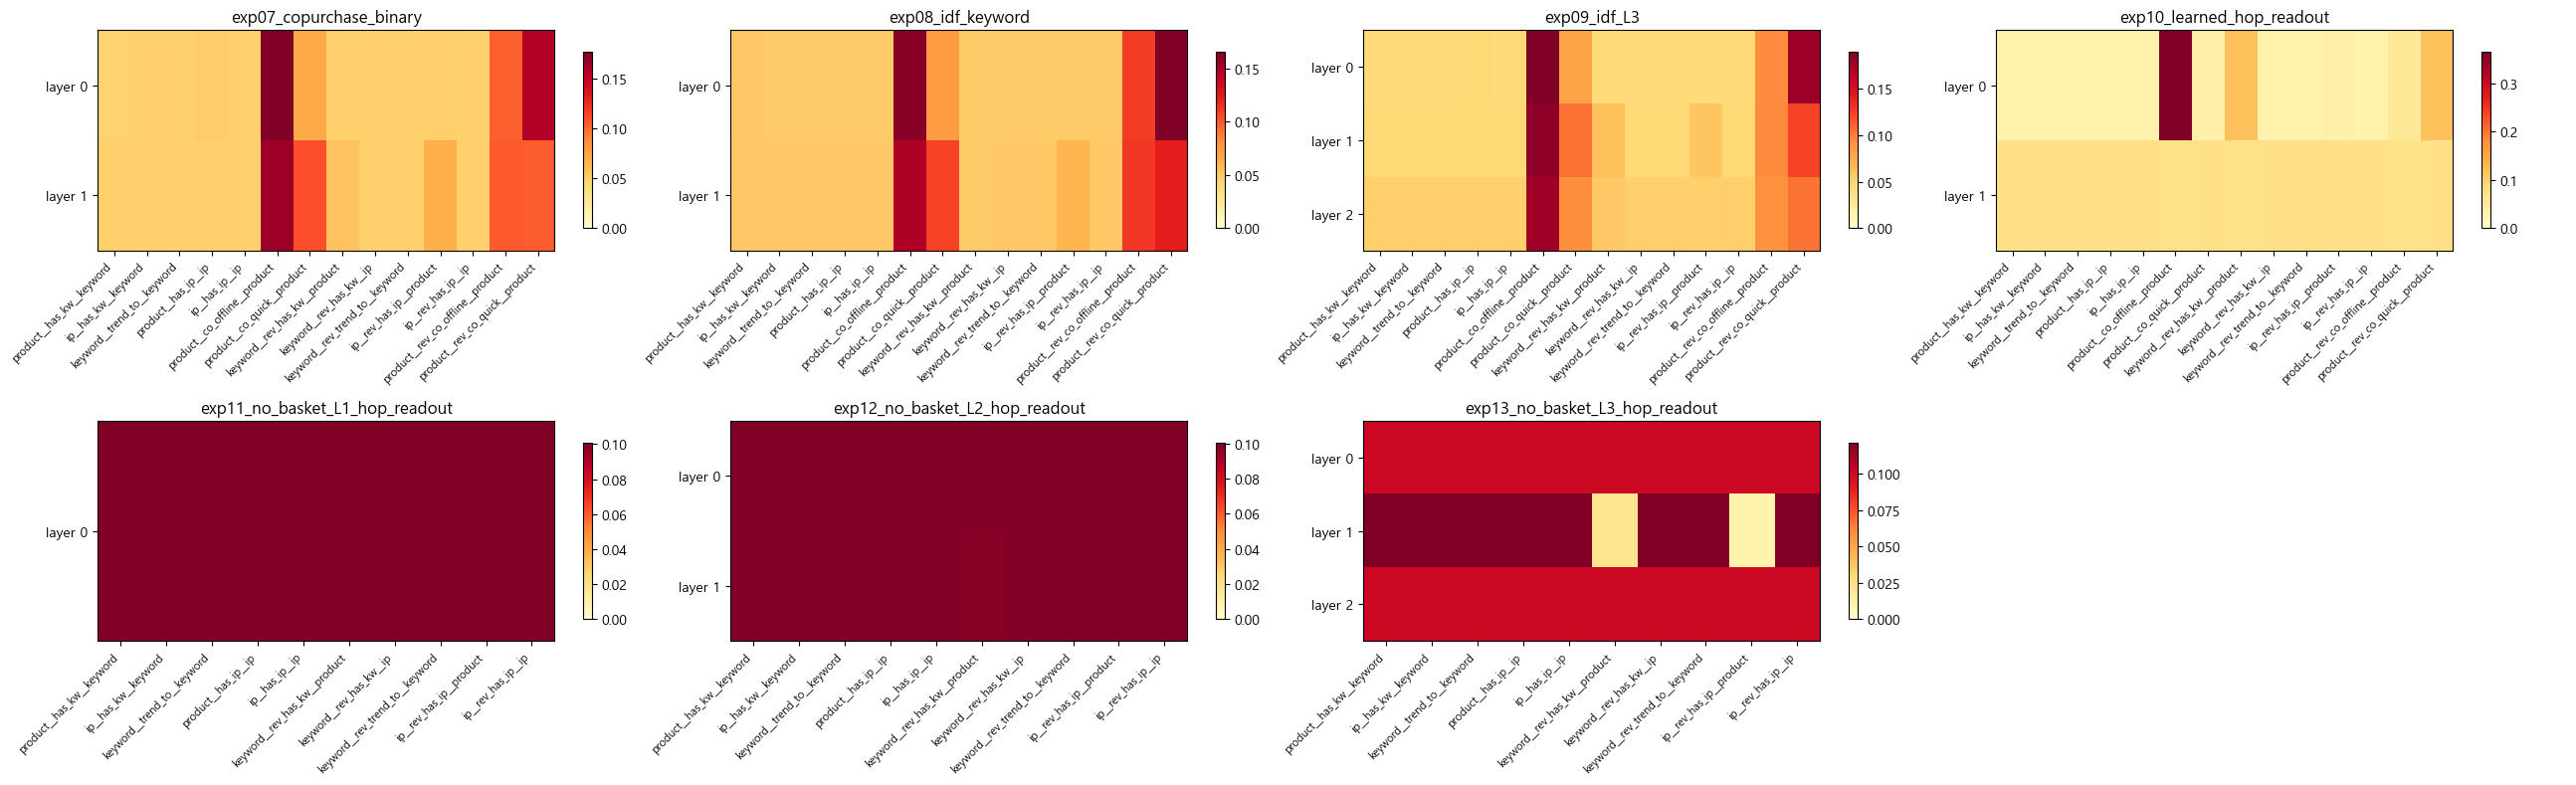

In [13]:
# 층별 DiffMG α_r 히트맵 — relation-specific depth가 학습됐는지 확인
# (basket이 layer-2에서 낮아지면 EDA의 per-edge L(basket=1)과 일치)
fig, axes = plt.subplots(2, 4, figsize=(26, 8))
axes = axes.ravel()
names = [
    'exp07_copurchase_binary',
    'exp08_idf_keyword',
    'exp09_idf_L3',
    'exp10_learned_hop_readout',
    'exp11_no_basket_L1_hop_readout',
    'exp12_no_basket_L2_hop_readout',
    'exp13_no_basket_L3_hop_readout',
]
for ax, name in zip(axes, names):
    try:
        plot_alpha_heatmap(name, ax=ax); ax.set_title(name)
    except Exception as e:
        ax.set_title(f'{name}\n(결과 없음: 먼저 실행)'); ax.text(0.5, 0.5, str(e)[:40], ha='center')
for ax in axes[len(names):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4. K-P-K 추천 (꿀조합) — 최종 산출물 sanity check

In [14]:
# K-P-K 추천 (꿀조합) — exp10이 성능을 이기면 이후 최종 influence readout 후보로 사용
print('=== exp07 baseline ===')
print_recommendations(r07)
print('\n=== exp10 learned hop readout ===')
print_recommendations(r10)
print('\n=== exp12 no-basket L2 learned hop readout ===')
print_recommendations(r12)

=== exp07 baseline ===
  마라 → 도쿠시마(0.0403), 향라(0.0399), 탄탄(0.0390), 샹궈(0.0154), 피(0.0135), 짜파게티(0.0133), 적음(0.0130), 자극적(0.0076), 곤약(0.0076), 누들(0.0061)
  로제 → 늘어남(0.0122), 마카로니(0.0081), 당면(0.0073), 고단백(0.0055), 중독성(0.0051), 파마산(0.0039), 납작(0.0037), 누들(0.0029), 하트(0.0024), 떡볶이(0.0024)
  흑임자 → 공룡(0.0229), 알(0.0099), 마카롱(0.0030), 묵직함(0.0022), 파운드케이크(0.0018), 작은별(0.0017), 시루떡(0.0014), 컵(0.0010), 바나나(0.0009), 적음(0.0008)
  단백질 → 헬스(0.0108), 엽떡(0.0106), 동물(0.0103), 베노프(0.0075), 소이조이(0.0054), 테이크핏(0.0052), 피쉬(0.0037), 청키(0.0036), 닥터유(0.0030), 비건(0.0029)
  위스키 → 블랙서클(0.0064), 산토리(0.0045), 예술(0.0018), 스카치(0.0008), 블론드(0.0005), 버번(0.0005), 글렌피딕(0.0004), 맥캘란(0.0004), 캐스크(0.0004), 클레이모어(0.0004)
  딸기 → 분홍(0.0044), 고칸(0.0040), 통크(0.0032), 치토스(0.0031), 몽쉘(0.0031), 톡핑(0.0027), 쌍둥이(0.0022), 트위스트(0.0022), 아모스(0.0021), 후루츄(0.0021)

=== exp10 learned hop readout ===
  마라 → 도쿠시마(0.0418), 향라(0.0410), 탄탄(0.0405), 샹궈(0.0198), 중독성(0.0154), 피(0.0137), 짜파게티(0.0137), 적음(0.0135), 곤약(0.0107), 자극적(0.0101)
  로제 → 늘어남

## 5. 결정 가이드

1. **IDF 효과**: exp07 vs exp08 의 test PR-AUC. 동등 이상이면 IDF 채택 (노이즈↓·해석력↑).
2. **L-sweep (parsimony)**: exp08(L2) vs exp09(L3).
   - L3가 L2를 **시드별 std 넘는 마진**으로 이기면 → L=3, 아니면 → **L=2**.
   - 시드 robust 비교가 필요하면 `run_experiment(..., overrides={"split.seed": s})`로 seed 3~5개 반복.
3. **Learned 1/2-hop readout**: exp10이 exp07을 test PR-AUC에서 이기면 `1-hop + 2-hop 영향력 가중합` 방향 채택. 못 이기면 최종 readout 후보에서 제외.
4. **No-basket L-sweep**: exp11~13은 모두 learned_hop_sum으로 고정. 동반구매 shortcut 제거 후에도 exp12(L=2)가 최선이면 L=2 prior 강화, exp13(L=3)이 noise margin 이상 이기면 no-basket 전용 L 재검토.
5. **α_r 히트맵**: basket(co_offline/co_quick)이 layer-2에서 낮으면 EDA per-edge L(basket=1)과 일치 — XAI 근거.
6. 확정 후 best 모델에 대해서만 전역/block influence map을 추출해 키워드 조합 + 상품/IP 근거 추천 리포트 생성.

## 6. dense A² 2홉 실험 (exp28 제품공간 + exp29 전체망 + 변형)

> **배경**: PR-AUC만 보면 1홉(exp27 0.691)이 이기지만, 1홉 모델은 추천 순회(K-P-K)를 못 하므로 **퇴화**다. 목적상 **2홉 영향**이 필수.
> 기존 2홉 후보(exp18/22 sim)는 **제품공간(P-K-P/P-I-P)** 만 봤고 K-K(트렌드)·I-K를 누락 → 전체 네트워크로 확장해 검증.
>
> **이 셀에 통합된 실험** (config로 표현 안 되는 커스텀 dense 모델 — `experiments/fullnet_dense_compare.py`):
> - **6a. exp28** — 제품공간(P×P) dense A² (직접 P-K 어텐션 누락 → 성능 낮음, 참고용)
> - **6b. exp29** — 전체망(N×N) dense A² base (`base(exp29)` 행)
> - **6c. 8변형** — 전체망 정규화(max/sym/row)·hop(1홉/2홉/합)·hidden·잔차 스윕
>
> **확정 방식**: dense 무임계 A² (`M=w₁A+w₂A²` → 공유 어텐션 → Hadamard). 임계컷 없음.
>
> 기준점: exp18(제품공간 sim) 0.6815 / exp10(전체망 스택) 0.678 / exp27(1홉, 퇴화) 0.691
>
> | 레버 | 후보 |
> |---|---|
> | 정규화 | `max`(전역최대) / `sym`(D^-1/2AD^-1/2, 허브 down-weight) / `row`(행정규화) |
> | hop | `sum`(w₁A+w₂A² 학습) / `a_only`(1홉) / `a2_only`(2홉) |
> | 용량 | hidden 128/64, 잔차 on/off |

In [15]:
# dense A² 2홉 실험 일괄 (exp28 제품공간 + exp29 전체망 base + 8변형)
# 무거운 모델/학습 코드는 experiments/fullnet_dense_compare.py 에 있음 (config로 표현 안 되는 커스텀 모델).
import torch, pandas as pd
from src.data_builder.build_hetero_data import build_graph
from experiments.fullnet_dense_compare import run_variant, run_product_space, VARIANTS, SEED

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data, _ = build_graph(seed=SEED, include_offline_copurchase=True, include_quick_copurchase=True,
                      use_lift_weights=False, add_2hop_edges=False)
P = data["product"].num_nodes; K = data["keyword"].num_nodes; I = data["ip"].num_nodes
print(f"P={P} K={K} I={I} | 전체망 N={P+K+I} | dense A²는 임계컷 없음\n")

rows = []
# 6a. exp28 — 제품공간(P×P) dense A²
try:
    r28 = run_product_space(data, P, K, I, dev); rows.append(r28)
    print(f"  [6a] {r28['name']:20s} test_pr={r28['test_pr']} auc={r28['test_auc']} peak={r28['peakGB']}GB")
except torch.cuda.OutOfMemoryError:
    print("  [6a] exp28 제품공간 → OOM"); torch.cuda.empty_cache()

# 6b+6c. exp29(전체망 base) + 8변형 — VARIANTS[0]='base(exp29)'가 곧 exp29
print("  [6b/6c] 전체망 dense 변형 (base(exp29) 포함):")
for cfg in VARIANTS:
    try:
        r = run_variant(data=data, P=P, K=K, I=I, dev=dev, **cfg); rows.append(r)
        tag = " ← exp29" if cfg['name'].startswith('base') else ""
        print(f"        {r['name']:16s} norm={r['norm']:3s} hop={r['hop']:7s} h={r['hid']} "
              f"| test_pr={r['test_pr']} auc={r['test_auc']} peak={r['peakGB']}GB{tag}")
    except torch.cuda.OutOfMemoryError:
        print(f"        {cfg['name']:16s} → OOM"); torch.cuda.empty_cache()

df_dense = pd.DataFrame(rows).sort_values("test_pr", ascending=False).reset_index(drop=True)
print("\n[참고] exp18 제품공간 sim 0.6815 / exp10 전체망 스택 0.678 / exp27 1홉(퇴화) 0.691")
try:
    from IPython.display import display; display(df_dense)
except Exception:
    print(df_dense.to_string())

P=5033 K=2063 I=335 | 전체망 N=7431 | dense A²는 임계컷 없음

  [6a] exp28_제품공간dense      test_pr=0.5819 auc=0.8064 peak=3.18GB
  [6b/6c] 전체망 dense 변형 (base(exp29) 포함):
        base(exp29)      norm=max hop=sum     h=128 | test_pr=0.6305 auc=0.839 peak=6.89GB ← exp29
        sym_norm         norm=sym hop=sum     h=128 | test_pr=0.608 auc=0.8357 peak=6.89GB
        row_norm         norm=row hop=sum     h=128 | test_pr=0.6321 auc=0.8408 peak=6.89GB
        sym+1hop         norm=sym hop=a_only  h=128 | test_pr=0.6754 auc=0.8506 peak=6.67GB
        sym+2hop         norm=sym hop=a2_only h=128 | test_pr=0.6242 auc=0.8348 peak=6.67GB
        sym+h64          norm=sym hop=sum     h=64 | test_pr=0.6084 auc=0.8287 peak=6.88GB
        sym+no_resid     norm=sym hop=sum     h=128 | test_pr=0.608 auc=0.8168 peak=6.89GB
        row+h64          norm=row hop=sum     h=64 | test_pr=0.6581 auc=0.8504 peak=6.88GB

[참고] exp18 제품공간 sim 0.6815 / exp10 전체망 스택 0.678 / exp27 1홉(퇴화) 0.691


,name,test_pr,test_auc,val_pr,hopw,peakGB,norm,hop,hid,heads,residual,epochs
0,sym+1hop,0.6754,0.8506,0.7267,None,6.67,sym,a_only,128.0,4.0,True,46.0
1,row+h64,0.6581,0.8504,0.7063,"[0.535, 0.465]",6.88,row,sum,64.0,4.0,True,55.0
2,row_norm,0.6321,0.8408,0.6815,"[0.52, 0.48]",6.89,row,sum,128.0,4.0,True,53.0
3,base(exp29),0.6305,0.8390,0.6724,"[0.527, 0.473]",6.89,max,sum,128.0,4.0,True,57.0
4,sym+2hop,0.6242,0.8348,0.6762,None,6.67,sym,a2_only,128.0,4.0,True,99.0
5,sym+h64,0.6084,0.8287,0.6389,"[0.537, 0.463]",6.88,sym,sum,64.0,4.0,True,54.0
6,sym_norm,0.6080,0.8357,0.6253,"[0.524, 0.476]",6.89,sym,sum,128.0,4.0,True,49.0
7,sym+no_resid,0.6080,0.8168,0.6451,"[0.549, 0.451]",6.89,sym,sum,128.0,4.0,False,60.0
8,exp28_제품공간dense,0.5819,0.8064,0.5934,"[0.566, 0.434]",3.18,NaN,NaN,NaN,NaN,NaN,NaN


## 7. exp30 — Semantic Fusion (정제 3중 행렬) vs exp18

> **설계 정제**: 5중 dense 행렬에서 전체 dense 2홉(`A_2hop_PK`, `A_2hop_PI`) 제거.
> 이유 — sim 엣지가 곧 **2홉의 유의미 부분집합**이라, 전체 dense 2홉은 (1) sim과 **공선성** (2) 거른 **노이즈 재유입** (3) 연산 폭증을 부른다.
>
> **3중 행렬** (전부 sym 정규화, K-K·I-K 제외):
> - $\hat{A}_{1hop\_all}$ = P-P(영수증) ∪ P-K ∪ P-I
> - $\hat{A}_{sim\_ip}$ = P-I-P 공유 ≥1 (IP는 1개도 강신호, 커버리지↑)
> - $\hat{A}_{sim\_kw}$ = P-K-P 공유 ≥5 (노이즈 차단)
>
> $M = g_1\hat{A}_{1hop} + g_2\hat{A}_{sim\_ip} + g_3\hat{A}_{sim\_kw}$ (DiffMG 게이트) → 공유 어텐션 ⊙ M → **1층** readout.
>
> **비교**: exp18(제품공간 sim) **0.6815** = 현재 최고 2홉 모델. 차이 = sim_ip ≥1(vs ≥2)·K-K/I-K 제외·전체망 공유어텐션.
>
> ⚠️ K-K·I-K 제외는 **제품라벨엔 최적**이나, 추천(K-P-K) readout엔 트렌드 전파가 필요(05 Phase 10) — 추천 단계에선 별도 고려.

In [16]:
# exp30 — Semantic Fusion (정제 3중 행렬) 실행 + exp18 비교
import torch
from experiments.fullnet_dense_compare import run_semantic_fusion, SEED
from src.data_builder.build_hetero_data import build_graph

if 'data' not in globals():
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data, _ = build_graph(seed=SEED, include_offline_copurchase=True, include_quick_copurchase=True,
                          use_lift_weights=False, add_2hop_edges=False)
    P = data["product"].num_nodes; K = data["keyword"].num_nodes; I = data["ip"].num_nodes

r30 = run_semantic_fusion(data, P, K, I, dev, sim_kw_thr=5, sim_ip_thr=1)
print("exp30 Semantic Fusion (3중 행렬):")
print(f"  test PR-AUC = {r30['test_pr']}   AUC = {r30['test_auc']}   peak = {r30['peakGB']}GB")
print(f"  게이트 가중(1hop/sim_ip/sim_kw) = {r30['gate(1hop/sim_ip/sim_kw)']}")
print(f"  엣지 수 nnz = {r30['nnz']}")
print(f"\n  [비교] exp18 제품공간 sim 0.6815 / exp27 1홉(퇴화) 0.691 / sym+1hop 전체망 0.679")
_delta = r30['test_pr'] - 0.6815
print(f"  exp30 vs exp18 : {'+' if _delta>=0 else ''}{_delta:.4f}  → "
      + ("exp30 우세" if _delta > 0.003 else "exp18 우세" if _delta < -0.003 else "사실상 동률(시드 노이즈)"))

exp30 Semantic Fusion (3중 행렬):
  test PR-AUC = 0.5822   AUC = 0.8152   peak = 7.11GB
  게이트 가중(1hop/sim_ip/sim_kw) = [0.351, 0.332, 0.317]
  엣지 수 nnz = {'1hop': 79920, 'sim_ip': 19776, 'sim_kw': 85142}

  [비교] exp18 제품공간 sim 0.6815 / exp27 1홉(퇴화) 0.691 / sym+1hop 전체망 0.679
  exp30 vs exp18 : -0.0993  → exp18 우세
